# Tools and Dependencies

In [1]:
import seaborn as sns
import matplotlib.pyplot as plot
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Exploration and Analysis of Dataset

In [2]:
titanic = sns.load_dataset('titanic')
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
print(titanic)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_town alive  alo

# Dataset Preprocessing

Remove Rows with missing values

In [5]:
# Remove Rows with missing values
titanic = titanic.dropna()
print(f"Rows in dataset after removing rows with NaN entries : {len(titanic)}")
print(titanic)

Rows in dataset after removing rows with NaN entries : 182
     survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
1           1       1  female  38.0      1      0  71.2833        C  First   
3           1       1  female  35.0      1      0  53.1000        S  First   
6           0       1    male  54.0      0      0  51.8625        S  First   
10          1       3  female   4.0      1      1  16.7000        S  Third   
11          1       1  female  58.0      0      0  26.5500        S  First   
..        ...     ...     ...   ...    ...    ...      ...      ...    ...   
871         1       1  female  47.0      1      1  52.5542        S  First   
872         0       1    male  33.0      0      0   5.0000        S  First   
879         1       1  female  56.0      0      1  83.1583        C  First   
887         1       1  female  19.0      0      0  30.0000        S  First   
889         1       1    male  26.0      0      0  30.0000        C  First   

    

Encode/Map String values into integer values


In [6]:
# Features with String Values
non_num_features = titanic.select_dtypes(exclude=['number']).columns.tolist()
print(f"Features that are Non-numeric and need integer mapping : {non_num_features}")

for feature in non_num_features :
  unique_values = titanic[feature].unique()
  print(f"{feature} feature unique values : {unique_values}")
  mapping = {value : i for i,value in enumerate(unique_values)}
  titanic[feature] = titanic[feature].map(mapping)

print(titanic)


Features that are Non-numeric and need integer mapping : ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
sex feature unique values : ['female' 'male']
embarked feature unique values : ['C' 'S' 'Q']
class feature unique values : ['First', 'Third', 'Second']
Categories (3, object): ['First', 'Second', 'Third']
who feature unique values : ['woman' 'man' 'child']
adult_male feature unique values : [False  True]
deck feature unique values : ['C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']
embark_town feature unique values : ['Cherbourg' 'Southampton' 'Queenstown']
alive feature unique values : ['yes' 'no']
alone feature unique values : [False  True]
     survived  pclass  sex   age  sibsp  parch     fare  embarked class  who  \
1           1       1    0  38.0      1      0  71.2833         0     0    0   
3           1       1    0  35.0      1      0  53.1000         1     0    0   
6           0    

Analysing the Preprocessed Dataset using Correlation Heatmap

<Axes: >

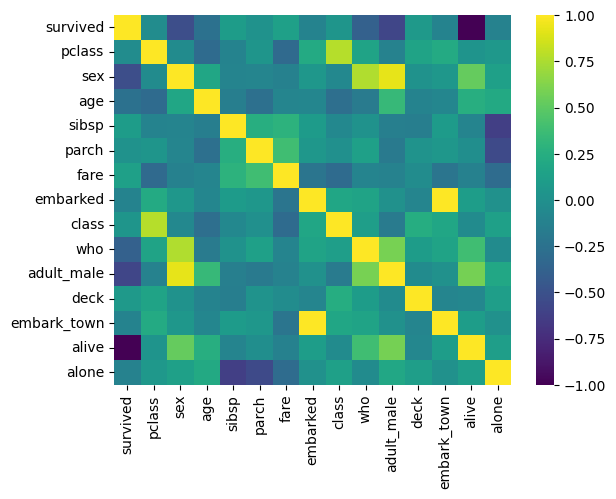

In [7]:
sns.heatmap(titanic.corr(), cmap='viridis')

Prepare Dataset for training and testing

In [8]:
# Drop 'alive' and 'alone' column because they are inverse of 'survived' column values. Model can predict just by inverting those values and doesn't learn useful information
X = titanic.drop(['survived','alive','alone'], axis=1)
Y = titanic['survived']
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.20, random_state=42) # Use random_state parameter to keep reproducibility or same training/tesing conditions.


# Model Selection and Training

Training, Testing and Tuning Hyperparameters of the Model

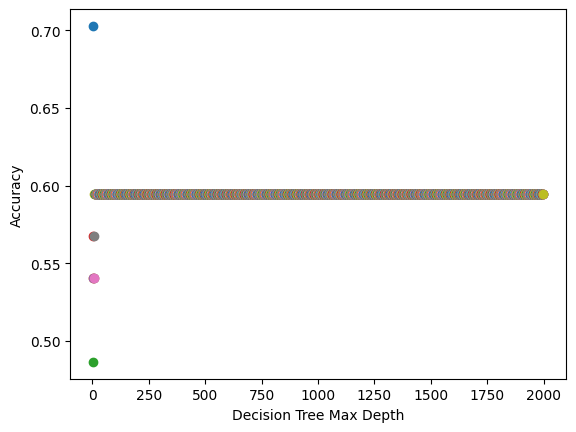

In [11]:
for depth in range(1,2000) :
  model = DecisionTreeClassifier(max_depth=depth, random_state=42)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  acc = accuracy_score(y_test,y_pred)
  plot.scatter(depth,acc)
plot.xlabel('Decision Tree Max Depth')
plot.ylabel('Accuracy')
plot.show()